과일/채소 분류 예측 결과: [[0.09172388 0.90827614]]
1차 분류: Vegetable (확률: 90.8%)
신선도 분류 예측 결과: [[0.0256241 0.9743759]]
신선도: Rotten (확률: 97.4%)
품목 분류 예측 결과: [[0.00148842 0.0216785  0.38428026 0.04307047 0.00511831 0.01136982
  0.01019025 0.00620088 0.01578321 0.01147424 0.00456114 0.46152723
  0.00817988 0.01507745]]
품목 분류: Potato (확률: 46.2%)


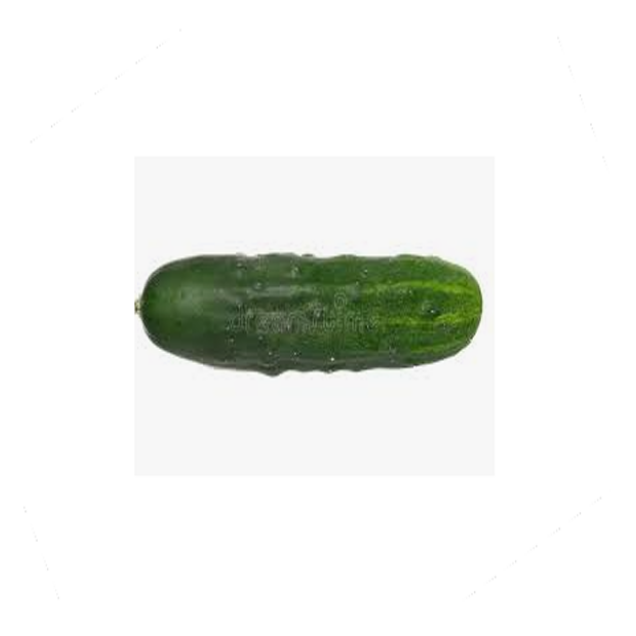

In [ ]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
import os
import json

# 모델 및 라벨 로드 함수
def load_custom_vision_model(model_dir):
    """Azure Custom Vision에서 내보낸 TensorFlow 모델을 로드합니다."""
    # 모델 파일 경로
    model_path = os.path.join(model_dir, "model.pb")
    # 라벨 파일 경로
    labels_path = os.path.join(model_dir, "labels.txt")
    
    if not os.path.exists(model_path):
        raise FileNotFoundError(f"Model file not found: {model_path}")
    
    if not os.path.exists(labels_path):
        raise FileNotFoundError(f"Labels file not found: {labels_path}")
    
    # 라벨 목록 로드
    with open(labels_path, 'r') as f:
        labels = [line.strip() for line in f.readlines()]
    
    
    # 그래프 로드
    with tf.io.gfile.GFile(model_path, 'rb') as f:
        graph_def = tf.compat.v1.GraphDef()
        graph_def.ParseFromString(f.read())
    
    # 그래프 생성
    with tf.compat.v1.Graph().as_default() as graph:
        tf.import_graph_def(graph_def, name='')
    
    # 세션 생성
    session = tf.compat.v1.Session(graph=graph)
    
    # 그래프의 모든 작업(operations) 출력 및 찾기
    operations = graph.get_operations()
    op_names = [op.name for op in operations]
    
    # 입력 텐서 찾기 (일반적으로 Placeholder)
    input_ops = [op for op in operations if op.type == 'Placeholder']
    if not input_ops:
        raise ValueError("No placeholder found in the graph")
    input_tensor = input_ops[0].outputs[0]
    
    # 출력 텐서 찾기 (일반적으로 마지막 연산)
    # 여러 후보 연산자들
    output_op_types = ['Softmax', 'Identity', 'Sigmoid', 'ArgMax', 'SpatialSoftmax']
    
    # 가능한 출력 연산을 찾기
    output_tensor = None
    for op_type in output_op_types:
        candidate_ops = [op for op in operations if op.type == op_type]
        if candidate_ops:
            # 가장 마지막 연산을 출력으로 선택 (일반적으로 가장 적합)
            output_tensor = candidate_ops[-1].outputs[0]
            break
    
    if output_tensor is None:
        # 출력 텐서를 찾지 못한 경우, 그래프의 마지막 연산을 사용
        output_tensor = operations[-1].outputs[0]
        print(f"Using last operation as output: {output_tensor}")
    
    return {
        'session': session,
        'input': input_tensor,
        'output': output_tensor,
        'labels': labels,
        'operations': op_names
    }

# 모델 파일 경로
model_dir = r"C:\Users\EL0021\Desktop\tenserflow_model"

tf_models = {
    "1-1": os.path.join(model_dir, "1-1.TensorFlow"),
    "2-1": os.path.join(model_dir, "2-1.TensorFlow"),
    "2-2": os.path.join(model_dir, "2-2.TensorFlow"),
    "3-1": os.path.join(model_dir, "3-1.TensorFlow"),
    "3-2": os.path.join(model_dir, "3-2.TensorFlow"),
}

# 모델 로드
models = {}
for key, path in tf_models.items():
    try:
        models[key] = load_custom_vision_model(path)
    except Exception as e:
        print(f"Failed to load model {key}: {e}")

# 이미지 전처리 함수
def preprocess_image(image_path):
    img = Image.open(image_path).resize((224, 224))
    img_array = np.array(img) / 255.0  # 정규화
    return np.expand_dims(img_array, axis=0)  # 배치 차원 추가

# 예측 함수
def predict_with_custom_model(model_dict, image):
    session = model_dict['session']
    input_tensor = model_dict['input']
    output_tensor = model_dict['output']
    
    # 세션 실행하여 예측
    predictions = session.run(output_tensor, {input_tensor: image})
    
    # 출력이 1D가 아닌 경우 (예: 2D 배열) 처리
    if len(predictions.shape) > 1:
        predictions = predictions
    else:
        # 1D 배열인 경우, 차원 추가
        predictions = np.expand_dims(predictions, axis=0)
        
    return predictions

# 1차 분류 (과일/채소)
def classify_fruit_veggie(image_path):
    if "1-1" not in models:
        return "모델 로드 실패", 0
    
    image = preprocess_image(image_path)
    predictions = predict_with_custom_model(models["1-1"], image)
    
    # 예측 결과 확인
    print(f"과일/채소 분류 예측 결과: {predictions}")
    
    labels = models["1-1"]["labels"]
    
    # 예측 결과의 형태에 따라 처리
    if predictions.size == len(labels):
        # 예측 결과가 라벨 수와 일치하는 경우
        predicted_index = np.argmax(predictions.flatten())
        confidence = float(predictions.flatten()[predicted_index]) * 100
    else:
        # 그 외의 경우, 형태 출력 후 첫 번째 인덱스 사용
        predicted_index = 0
        confidence = 0
    
    if predicted_index < len(labels):
        return labels[predicted_index], confidence
    else:
        return "인덱스 오류", 0

# 신선도 판별
def classify_freshness(category, image_path):
    # 과일/채소에 따라 적절한 모델 선택
    if "Fruit" in category:
        model_key = "2-1"
    else:
        model_key = "2-2"
    
    if model_key not in models:
        return "모델 로드 실패", 0
    
    image = preprocess_image(image_path)
    predictions = predict_with_custom_model(models[model_key], image)
    
    print(f"신선도 분류 예측 결과: {predictions}")
    
    labels = models[model_key]["labels"]
    
    # 예측 결과의 형태에 따라 처리
    if predictions.size == len(labels):
        predicted_index = np.argmax(predictions.flatten())
        confidence = float(predictions.flatten()[predicted_index]) * 100
    else:
        print(f"예측 형태: {predictions.shape}, 라벨 수: {len(labels)}")
        predicted_index = 0
        confidence = 0
    
    if predicted_index < len(labels):
        return labels[predicted_index], confidence
    else:
        return "인덱스 오류", 0

# 품목 분류
def classify_type(category, image_path):
    # 과일/채소에 따라 적절한 모델 선택
    if "Fruit" in category:
        model_key = "3-1"
    else:
        model_key = "3-2"
    
    if model_key not in models:
        return "모델 로드 실패", 0
    
    image = preprocess_image(image_path)
    predictions = predict_with_custom_model(models[model_key], image)
    
    print(f"품목 분류 예측 결과: {predictions}")
    
    labels = models[model_key]["labels"]
    
    # 예측 결과의 형태에 따라 처리
    if predictions.size == len(labels):
        predicted_index = np.argmax(predictions.flatten())
        confidence = float(predictions.flatten()[predicted_index]) * 100
    else:
        print(f"예측 형태: {predictions.shape}, 라벨 수: {len(labels)}")
        predicted_index = 0
        confidence = 0
    
    if predicted_index < len(labels):
        return labels[predicted_index], confidence
    else:
        return "인덱스 오류", 0

# 결과 출력 함수
def analyze_image(image_path):
    if not os.path.exists(image_path):
        print(f"이미지 파일을 찾을 수 없습니다: {image_path}")
        return
        
    try:
        # 이미지 열기
        img = Image.open(image_path)
        
        # 이미지 표시
        plt.figure(figsize=(10, 8))
        plt.imshow(img)
        plt.axis('off')
        
        # 분류 실행
        category, cat_conf = classify_fruit_veggie(image_path)
        print(f"1차 분류: {category} (확률: {cat_conf:.1f}%)")
        
        # 카테고리가 제대로 인식된 경우에만 신선도 및 품목 분류
        if "실패" not in category and "오류" not in category:
            freshness, fresh_conf = classify_freshness(category, image_path)
            print(f"신선도: {freshness} (확률: {fresh_conf:.1f}%)")
            
            item_type, type_conf = classify_type(category, image_path)
            print(f"품목 분류: {item_type} (확률: {type_conf:.1f}%)")
            
        else:
            print("모델 로드에 실패하여 추가 분석을 진행할 수 없습니다.")
        
        plt.show()
        
    except Exception as e:
        print(f"이미지 분석 중 오류 발생: {e}")
        import traceback
        traceback.print_exc()

# 테스트 실행
image_path = r"YOUR-IMAGE"
analyze_image(image_path)

# 세션 정리 (리소스 해제)
def cleanup():
    for model_dict in models.values():
        if 'session' in model_dict:
            model_dict['session'].close()

# 프로그램 종료 시 세션 정리
cleanup()